In [2]:
from datetime import date, datetime

import polars as pl

from core.columns import SYMBOL, DATE, TRADE_TIME
from core.currency_pair import CurrencyPair
from core.exchange import Exchange
from core.time_utils import Bounds

In [3]:
bounds: Bounds = Bounds.for_day(date(2021, 9, 5))
currency_pair: CurrencyPair = CurrencyPair.from_string("VIB-BTC")

hive: pl.LazyFrame = pl.scan_parquet(
    Exchange.BINANCE_SPOT.get_hive_location(), hive_partitioning=True
)

In [4]:
data = (
    hive.filter(
        (pl.col(SYMBOL) == currency_pair.name) &
        (pl.col(DATE).is_between(bounds.day0, bounds.day1)) &
        (pl.col(TRADE_TIME).is_between(bounds.start_inclusive, bounds.end_exclusive))
    )
    .collect()
    .sort(by=TRADE_TIME)
    .to_pandas()
    .set_index(TRADE_TIME)
)

In [5]:
candles = (
    data
    .resample("1s")
    .agg(
        Open=("price", "first"),
        Low=("price", "min"),
        High=("price", "max"),
        Close=("price", "last"),
        Volume=("quantity", "sum"),
    )
)

candles.head(2)

,Open,Low,High,Close,Volume
trade_time,,,,,
2021-09-05 00:01:12,0.000001,0.000001,0.000001,0.000001,19288.0
2021-09-05 00:01:13,NaN,NaN,NaN,NaN,0.0


In [6]:
start: datetime = datetime(2021, 9, 5, 16, 59)
end: datetime = datetime(2021, 9, 5, 17, 1)

data_plot = candles[(candles.index >= start) & (candles.index < end)]

In [7]:
import mplfinance as mpf

/tmp/ipykernel_88159/1846024521.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


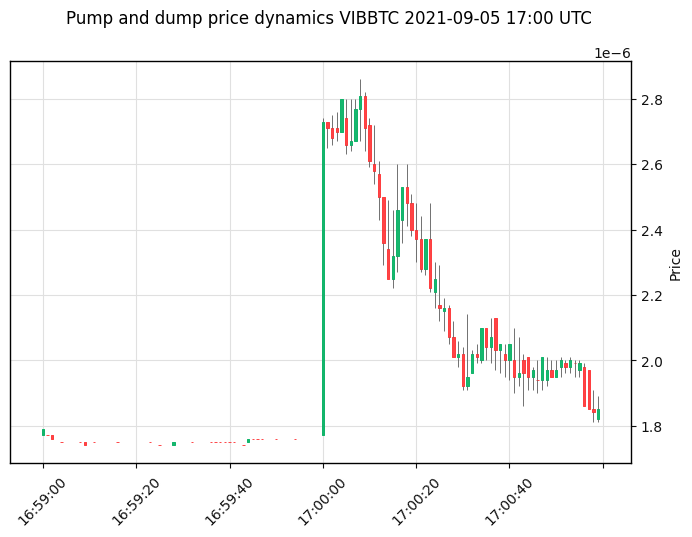

In [51]:
import matplotlib as mpl
import mplfinance as mpf

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # use TNR for all text (title, labels, ticks)
    "axes.titleweight": "normal",
})

s = mpf.make_mpf_style(
    base_mpf_style='yahoo',
    facecolor='none',
    figcolor='none',
    gridstyle='-',
    gridcolor='#e0e0e0',
    rc={'axes.grid': True, 'savefig.transparent': True}
)

fig, axlist = mpf.plot(
    data_plot,
    type='candle',
    style=s,
    title='',  # we'll add a figure-wide title below
    ylabel='Price',
    datetime_format='%H:%M:%S',
    figratio=(6, 4),
    returnfig=True,
)

fig.suptitle(
    'Pump and dump price dynamics VIBBTC 2021-09-05 17:00 UTC',
    ha='center', va='top', x=0.55, y=0.97,
    fontsize=12, fontweight='normal'  # TNR is applied via rcParams above
)

axes = axlist if isinstance(axlist, (list, tuple)) else [axlist]
for ax in axes:
    ax.set_facecolor('none')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)
        spine.set_edgecolor('black')  # or '#888888' for softer box

fig.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig('images/pump_and_dump_example.png', dpi=600, bbox_inches='tight', pad_inches=0, transparent=True)

In [78]:
fig